# 04 Baseline TF-IDF Classifier

本 Notebook 比较以下模型：

1. 全局先验 baseline；
2. Party prior baseline；
3. Structured-only Logistic Regression；
4. Word TF-IDF；
5. Word + character TF-IDF；
6. TF-IDF + structured features。

模型选择只使用 Validation。默认不运行 Test，从而保留 Test 作为最后一次确认。

In [1]:
from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 140)

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'processed').exists():
    BASE_DIR = BASE_DIR / 'reorganised'

DATA_DIR = BASE_DIR / 'processed' / 'model_v2'
OUTPUT_DIR = DATA_DIR / 'baseline_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 默认只运行 Validation，避免在模型选择阶段查看 Test。
RUN_FINAL_TEST = False

# 这些是第一版产品验收门槛，可以根据项目目标调整。
MIN_VALIDATION_MACRO_F1 = 0.72
MIN_IMPROVEMENT_OVER_PARTY_BASELINE = 0.05
MIN_WORST_PARTY_MACRO_F1 = 0.60

RANDOM_STATE = 42
TARGET = 'target_binary_support'

print('Data directory:', DATA_DIR.resolve())
print('RUN_FINAL_TEST:', RUN_FINAL_TEST)

Data directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/model_v2
RUN_FINAL_TEST: False


## 1. Load the frozen data

Train、Validation 和 Test 已按 division 和时间切分。本 Notebook 不重新切分数据。

In [2]:
train = pd.read_csv(DATA_DIR / 'model_train_v2.csv', parse_dates=['motion_date'])
validation = pd.read_csv(DATA_DIR / 'model_validation_v2.csv', parse_dates=['motion_date'])
test = pd.read_csv(DATA_DIR / 'model_test_v2.csv', parse_dates=['motion_date'])

assert train['row_id'].is_unique
assert validation['row_id'].is_unique
assert test['row_id'].is_unique
assert not set(train['division_key']) & set(validation['division_key'])
assert not set(train['division_key']) & set(test['division_key'])
assert not set(validation['division_key']) & set(test['division_key'])
assert set(train[TARGET].astype(int).unique()) == {0, 1}
assert set(validation[TARGET].astype(int).unique()) == {0, 1}
assert set(test[TARGET].astype(int).unique()) == {0, 1}

dataset_overview = pd.DataFrame({
    'rows': [len(train), len(validation), len(test)],
    'divisions': [
        train['division_key'].nunique(),
        validation['division_key'].nunique(),
        test['division_key'].nunique(),
    ],
    'support_rate': [
        train[TARGET].mean(),
        validation[TARGET].mean(),
        test[TARGET].mean(),
    ],
}, index=['train', 'validation', 'test'])
display(dataset_overview.round(3))

,rows,divisions,support_rate
train,2822,770,0.569
validation,570,169,0.591
test,1289,354,0.578


## 2. Define leakage-safe features

TF-IDF 仅在 `fit(train)` 时学习词表和 IDF。Validation/Test 只调用 `predict_proba`。

In [3]:
TEXT_COLUMN = 'model_text'

CATEGORICAL_COLUMNS = [
    'party',
    'party_role',
    'party_object_alignment',
    'motion_type',
    'motion_family',
    'policy_domain_primary',
    'policy_domain_confidence',
    'government_party',
    'main_opposition_party',
]

NUMERIC_COLUMNS = [
    'motion_year',
    'motion_month',
    'years_since_2016',
    'motion_char_count',
    'motion_word_count',
    'model_text_char_count',
    'model_text_word_count',
    'total_possible_members',
    'has_legislation_name',
    'bill_link_available',
    'is_governing_party',
    'is_main_opposition',
    'is_opposition_day',
    'is_amendment',
    'is_new_clause',
    'is_financial_motion',
    'government_backing_known',
    'final_object_government_backed',
    'legacy_domain_count',
    'policy_domain_count',
    'is_econ_finance',
    'is_justice_security',
    'is_env_infra',
    'is_social_health',
    'is_national_affairs',
]

FORBIDDEN_FEATURES = {
    'party_result', 'raw_vote_score', 'party_for', 'party_against',
    'party_for_percentage', 'party_majority', 'total_for', 'total_against',
    'total_result', 'target_policy_result', 'target_policy_stance_score',
    'target_policy_stance', 'target_ordinal_provisional', TARGET,
}

selected_features = {TEXT_COLUMN, *CATEGORICAL_COLUMNS, *NUMERIC_COLUMNS}
assert not selected_features & FORBIDDEN_FEATURES

missing_columns = selected_features - set(train.columns)
assert not missing_columns, f'Missing feature columns: {sorted(missing_columns)}'

print('Text columns:', 1)
print('Categorical columns:', len(CATEGORICAL_COLUMNS))
print('Numeric columns:', len(NUMERIC_COLUMNS))

Text columns: 1
Categorical columns: 9
Numeric columns: 25


## 3. Evaluation functions

In [4]:
def evaluate_probabilities(y_true, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_true, predictions),
        'macro_f1': f1_score(y_true, predictions, average='macro', zero_division=0),
        'support_precision': precision_score(y_true, predictions, zero_division=0),
        'support_recall': recall_score(y_true, predictions, zero_division=0),
        'support_f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probabilities),
        'log_loss': log_loss(y_true, probabilities, labels=[0, 1]),
        'brier': brier_score_loss(y_true, probabilities),
        'threshold': threshold,
    }


def subgroup_metrics(frame, probabilities, group_column, threshold):
    work = frame[[group_column, TARGET]].copy()
    work['probability'] = np.asarray(probabilities)
    work['prediction'] = work['probability'].ge(threshold).astype(int)
    rows = []
    for group, subset in work.groupby(group_column, dropna=False):
        if subset[TARGET].nunique() < 2:
            macro_f1 = np.nan
            balanced_accuracy = np.nan
        else:
            macro_f1 = f1_score(
                subset[TARGET], subset['prediction'], average='macro', zero_division=0
            )
            balanced_accuracy = balanced_accuracy_score(
                subset[TARGET], subset['prediction']
            )
        rows.append({
            group_column: group,
            'rows': len(subset),
            'support_rate': subset[TARGET].mean(),
            'accuracy': accuracy_score(subset[TARGET], subset['prediction']),
            'balanced_accuracy': balanced_accuracy,
            'macro_f1': macro_f1,
        })
    return pd.DataFrame(rows).sort_values('macro_f1', na_position='last')


def find_best_threshold(y_true, probabilities):
    candidates = np.round(np.arange(0.25, 0.751, 0.01), 2)
    scores = [
        f1_score(
            y_true,
            (np.asarray(probabilities) >= threshold).astype(int),
            average='macro',
            zero_division=0,
        )
        for threshold in candidates
    ]
    best_index = int(np.argmax(scores))
    return float(candidates[best_index]), float(scores[best_index])

## 4. Simple baselines

Party prior 只使用 Train 中每个政党的历史支持率，是组合模型必须超过的业务 baseline。

In [5]:
y_train = train[TARGET].astype(int)
y_validation = validation[TARGET].astype(int)

validation_rows = []
validation_probabilities = {}

# 全局先验对所有记录输出相同概率。
global_prior = float(y_train.mean())
global_probabilities = np.full(len(validation), global_prior)
global_metrics = evaluate_probabilities(y_validation, global_probabilities)
global_metrics['model'] = 'global_prior'
global_metrics['fit_seconds'] = 0.0
validation_rows.append(global_metrics)
validation_probabilities['global_prior'] = global_probabilities

# Party prior 使用 Train 中各政党的平均支持率。
party_prior_table = train.groupby('party')[TARGET].mean()
party_probabilities = validation['party'].map(party_prior_table).fillna(global_prior).to_numpy()
party_metrics = evaluate_probabilities(y_validation, party_probabilities)
party_metrics['model'] = 'party_prior'
party_metrics['fit_seconds'] = 0.0
validation_rows.append(party_metrics)
validation_probabilities['party_prior'] = party_probabilities

display(party_prior_table.rename('train_support_rate').to_frame().round(3))

,train_support_rate
party,
conservative,0.494
green,0.585
labour,0.596
liberal-democrat,0.610


## 5. Model pipelines

In [6]:
def make_classifier():
    return LogisticRegression(
        solver='liblinear',
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    )


def make_structured_transformer():
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ])
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ('categorical', categorical_pipeline, CATEGORICAL_COLUMNS),
        ('numeric', numeric_pipeline, NUMERIC_COLUMNS),
    ], remainder='drop')


def make_word_tfidf():
    return TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=30000,
        sublinear_tf=True,
    )


def make_char_tfidf():
    return TfidfVectorizer(
        analyzer='char_wb',
        lowercase=True,
        ngram_range=(3, 5),
        min_df=3,
        max_features=30000,
        sublinear_tf=True,
    )


model_templates = {
    'structured_only': Pipeline([
        ('features', make_structured_transformer()),
        ('classifier', make_classifier()),
    ]),
    'tfidf_word': Pipeline([
        ('features', ColumnTransformer([
            ('word', make_word_tfidf(), TEXT_COLUMN),
        ], remainder='drop')),
        ('classifier', make_classifier()),
    ]),
    'tfidf_word_char': Pipeline([
        ('features', ColumnTransformer([
            ('word', make_word_tfidf(), TEXT_COLUMN),
            ('char', make_char_tfidf(), TEXT_COLUMN),
        ], remainder='drop')),
        ('classifier', make_classifier()),
    ]),
    'tfidf_plus_structured': Pipeline([
        ('features', ColumnTransformer([
            ('word', make_word_tfidf(), TEXT_COLUMN),
            ('char', make_char_tfidf(), TEXT_COLUMN),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('one_hot', OneHotEncoder(handle_unknown='ignore')),
            ]), CATEGORICAL_COLUMNS),
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scale', StandardScaler(with_mean=False)),
            ]), NUMERIC_COLUMNS),
        ], remainder='drop')),
        ('classifier', make_classifier()),
    ]),
}

print('Candidate models:', list(model_templates))

Candidate models: ['structured_only', 'tfidf_word', 'tfidf_word_char', 'tfidf_plus_structured']


## 6. Fit candidates on Train and evaluate on Validation

这里只选择模型，不访问 Test。

In [7]:
fitted_models = {}

for model_name, template in model_templates.items():
    model = clone(template)
    started = time.perf_counter()
    model.fit(train, y_train)
    fit_seconds = time.perf_counter() - started

    probabilities = model.predict_proba(validation)[:, 1]
    metrics = evaluate_probabilities(y_validation, probabilities)
    metrics['model'] = model_name
    metrics['fit_seconds'] = fit_seconds

    fitted_models[model_name] = model
    validation_probabilities[model_name] = probabilities
    validation_rows.append(metrics)
    print(f'{model_name}: macro_f1={metrics["macro_f1"]:.3f}, fit={fit_seconds:.1f}s')

validation_comparison = (
    pd.DataFrame(validation_rows)
    .set_index('model')
    .sort_values('macro_f1', ascending=False)
)
validation_comparison.to_csv(OUTPUT_DIR / 'validation_model_comparison.csv')
display(validation_comparison.round(3))

structured_only: macro_f1=0.566, fit=0.0s
tfidf_word: macro_f1=0.561, fit=0.2s
tfidf_word_char: macro_f1=0.571, fit=1.0s
tfidf_plus_structured: macro_f1=0.568, fit=1.7s


,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,support_f1,roc_auc,log_loss,brier,threshold,fit_seconds
model,,,,,,,,,,,
party_prior,0.670,0.634,0.635,0.681,0.831,0.749,0.641,0.654,0.231,0.5,0.000
tfidf_word_char,0.584,0.572,0.571,0.651,0.641,0.646,0.571,0.694,0.250,0.5,1.038
tfidf_plus_structured,0.570,0.576,0.568,0.667,0.546,0.600,0.653,0.697,0.248,0.5,1.689
structured_only,0.567,0.581,0.566,0.681,0.501,0.578,0.667,0.689,0.241,0.5,0.022
tfidf_word,0.575,0.561,0.561,0.642,0.638,0.640,0.576,0.692,0.249,0.5,0.183
global_prior,0.591,0.500,0.372,0.591,1.000,0.743,0.500,0.677,0.242,0.5,0.000


## 7. Select the model and tune its threshold on Validation

In [8]:
candidate_names = list(model_templates)
selected_model_name = validation_comparison.loc[candidate_names, 'macro_f1'].idxmax()
selected_model = fitted_models[selected_model_name]
selected_validation_probabilities = validation_probabilities[selected_model_name]

selected_threshold, tuned_validation_macro_f1 = find_best_threshold(
    y_validation,
    selected_validation_probabilities,
)
selected_validation_metrics = evaluate_probabilities(
    y_validation,
    selected_validation_probabilities,
    threshold=selected_threshold,
)

validation_party_metrics = subgroup_metrics(
    validation,
    selected_validation_probabilities,
    'party',
    selected_threshold,
)
validation_domain_metrics = subgroup_metrics(
    validation,
    selected_validation_probabilities,
    'policy_domain_primary',
    selected_threshold,
)

party_prior_macro_f1 = float(validation_comparison.loc['party_prior', 'macro_f1'])
improvement_over_party_prior = selected_validation_metrics['macro_f1'] - party_prior_macro_f1
worst_party_macro_f1 = float(validation_party_metrics['macro_f1'].dropna().min())

acceptance_checks = {
    'macro_f1_gate': selected_validation_metrics['macro_f1'] >= MIN_VALIDATION_MACRO_F1,
    'party_prior_improvement_gate': improvement_over_party_prior >= MIN_IMPROVEMENT_OVER_PARTY_BASELINE,
    'worst_party_gate': worst_party_macro_f1 >= MIN_WORST_PARTY_MACRO_F1,
}
validation_passes = all(acceptance_checks.values())
p2_recommendation = (
    'P2 can be deferred for the MVP.'
    if validation_passes
    else 'Review P2 before freezing the final model.'
)

display(pd.Series({
    'selected_model': selected_model_name,
    'selected_threshold': selected_threshold,
    'validation_macro_f1': selected_validation_metrics['macro_f1'],
    'party_prior_macro_f1': party_prior_macro_f1,
    'improvement_over_party_prior': improvement_over_party_prior,
    'worst_party_macro_f1': worst_party_macro_f1,
    'passes_all_gates': validation_passes,
    'p2_recommendation': p2_recommendation,
}, name='value').to_frame())

display(validation_party_metrics.round(3))

,value
selected_model,tfidf_word_char
selected_threshold,0.5
validation_macro_f1,0.571278
party_prior_macro_f1,0.634536
improvement_over_party_prior,-0.063258
worst_party_macro_f1,0.316183
passes_all_gates,False
p2_recommendation,Review P2 before freezing the final model.


,party,rows,support_rate,accuracy,balanced_accuracy,macro_f1
0,conservative,159,0.358,0.321,0.324,0.316
2,labour,151,0.629,0.609,0.594,0.591
1,green,135,0.696,0.674,0.670,0.648
3,liberal-democrat,125,0.728,0.792,0.802,0.764


## 8. Validation plots

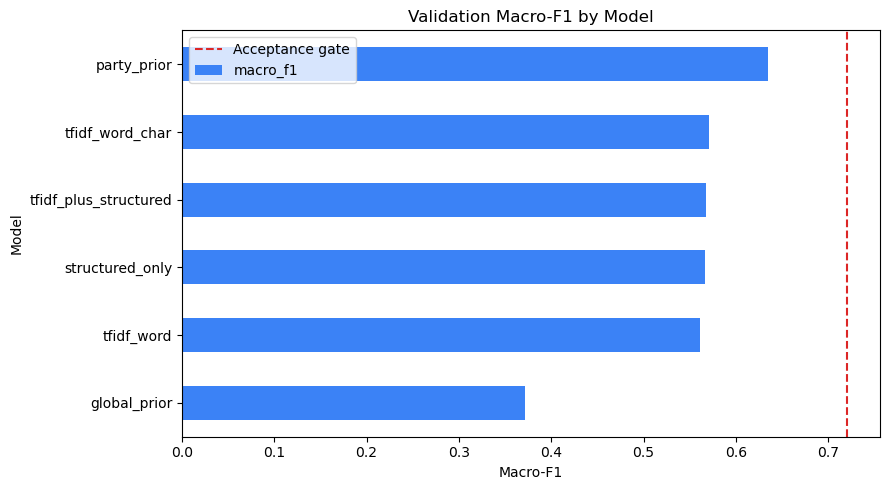

,Predicted oppose,Predicted support
Actual oppose,117,116
Actual support,121,216


In [9]:
plot_order = validation_comparison.sort_values('macro_f1').index
ax = validation_comparison.loc[plot_order, 'macro_f1'].plot(
    kind='barh', figsize=(9, 5), color='#3B82F6'
)
ax.axvline(MIN_VALIDATION_MACRO_F1, color='#DC2626', linestyle='--', label='Acceptance gate')
ax.set_title('Validation Macro-F1 by Model')
ax.set_xlabel('Macro-F1')
ax.set_ylabel('Model')
ax.legend()
plt.tight_layout()
plt.show()

selected_validation_predictions = (
    selected_validation_probabilities >= selected_threshold
).astype(int)
validation_confusion = confusion_matrix(y_validation, selected_validation_predictions)
display(pd.DataFrame(
    validation_confusion,
    index=['Actual oppose', 'Actual support'],
    columns=['Predicted oppose', 'Predicted support'],
))

## 9. Optional final Test

只有在 Validation 决策完成后才将 `RUN_FINAL_TEST` 改为 `True`。一旦查看 Test，就不应继续根据 Test 调整模型。

In [10]:
test_summary = None

if not RUN_FINAL_TEST:
    print('Test was not run. Decide whether P2 is needed from the Validation summary first.')
else:
    y_test = test[TARGET].astype(int)
    test_probabilities = selected_model.predict_proba(test)[:, 1]
    test_metrics = evaluate_probabilities(
        y_test,
        test_probabilities,
        threshold=selected_threshold,
    )
    test_party_metrics = subgroup_metrics(
        test, test_probabilities, 'party', selected_threshold
    )
    test_domain_metrics = subgroup_metrics(
        test, test_probabilities, 'policy_domain_primary', selected_threshold
    )

    test_predictions = (test_probabilities >= selected_threshold).astype(int)
    bad_cases = test[[
        'row_id', 'division_key', 'motion_date', 'party', 'party_role',
        'motion_title_clean', 'motion_type', 'policy_domain_primary', TARGET,
    ]].copy()
    bad_cases['predicted_support'] = test_predictions
    bad_cases['support_probability'] = test_probabilities
    bad_cases['confidence'] = np.abs(test_probabilities - 0.5) * 2
    bad_cases = bad_cases.loc[
        bad_cases[TARGET].astype(int).ne(bad_cases['predicted_support'])
    ].sort_values('confidence', ascending=False)

    validation_comparison.to_csv(OUTPUT_DIR / 'validation_model_comparison.csv')
    pd.DataFrame([test_metrics]).to_csv(OUTPUT_DIR / 'selected_model_test_metrics.csv', index=False)
    test_party_metrics.to_csv(OUTPUT_DIR / 'selected_model_test_by_party.csv', index=False)
    test_domain_metrics.to_csv(OUTPUT_DIR / 'selected_model_test_by_domain.csv', index=False)
    bad_cases.head(100).to_csv(OUTPUT_DIR / 'selected_model_bad_cases.csv', index=False)
    joblib.dump(selected_model, OUTPUT_DIR / 'selected_model.joblib')

    test_summary = {
        'selected_model': selected_model_name,
        'threshold': selected_threshold,
        **{key: float(value) for key, value in test_metrics.items()},
    }
    with (OUTPUT_DIR / 'final_test_summary.json').open('w', encoding='utf-8') as file:
        json.dump(test_summary, file, ensure_ascii=False, indent=2)

    display(pd.Series(test_summary, name='value').to_frame())
    display(test_party_metrics.round(3))
    display(bad_cases.head(20))

Test was not run. Decide whether P2 is needed from the Validation summary first.


## 10. Summary for review

运行后只需要把下面这个 Cell 的文本输出发回，不需要复制前面的表格。

In [11]:
print('=== SUMMARY FOR REVIEW ===')
print(f'Selected model: {selected_model_name}')
print(f'Validation threshold: {selected_threshold:.2f}')
print(f'Validation Macro-F1: {selected_validation_metrics["macro_f1"]:.3f}')
print(f'Validation Accuracy: {selected_validation_metrics["accuracy"]:.3f}')
print(f'Party-prior Macro-F1: {party_prior_macro_f1:.3f}')
print(f'Improvement over party prior: {improvement_over_party_prior:+.3f}')
print(f'Worst-party Macro-F1: {worst_party_macro_f1:.3f}')
print(f'Acceptance gates: {acceptance_checks}')
print(f'P2 recommendation: {p2_recommendation}')
print(f'RUN_FINAL_TEST: {RUN_FINAL_TEST}')
if test_summary is None:
    print('Test result: NOT RUN')
else:
    print(f'Test Macro-F1: {test_summary["macro_f1"]:.3f}')
    print(f'Test Accuracy: {test_summary["accuracy"]:.3f}')
print('=== END SUMMARY ===')

=== SUMMARY FOR REVIEW ===
Selected model: tfidf_word_char
Validation threshold: 0.50
Validation Macro-F1: 0.571
Validation Accuracy: 0.584
Party-prior Macro-F1: 0.635
Improvement over party prior: -0.063
Worst-party Macro-F1: 0.316
Acceptance gates: {'macro_f1_gate': False, 'party_prior_improvement_gate': False, 'worst_party_gate': False}
P2 recommendation: Review P2 before freezing the final model.
RUN_FINAL_TEST: False
Test result: NOT RUN
=== END SUMMARY ===
